# Cell 1 — Import library

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Cell 2 — Tentukan folder project

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_TABLES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED_DIR)
print("Output tables dir:", OUTPUT_TABLES_DIR)
print("Output figures dir:", OUTPUT_FIGURES_DIR)

Project root: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL
Processed dir: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\data\processed
Output tables dir: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables
Output figures dir: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures


# Cell 3 — Baca dataset fitur

In [3]:
FEATURE_PATH = PROCESSED_DIR / "08_features_process_mining_per_student.csv"

feature_df = pd.read_csv(FEATURE_PATH)

print("Ukuran feature_df:", feature_df.shape)
display(feature_df.head())

print("\nDistribusi label performance:")
display(feature_df["label_performance"].value_counts())

Ukuran feature_df: (89, 65)


,case_id,nim,nama,kelas,nilai_total,nilai_indeks,label_performance,total_events_full,unique_activity_full,total_events_compact,...,tr_submitted_to_quiz_module,variant_id,variant_frequency,variant_sequence,trace_is_fit,trace_fitness,missing_tokens,remaining_tokens,consumed_tokens,produced_tokens
0,ADITYA PUTRA PERMANA,103012530065,ADITYA PUTRA PERMANA,IF-49-02,73.01,B,Sedang,2413,17,1979,...,22,1,1,Course Viewed -> Material Viewed -> Course Vie...,1,1.0,0,0,3866,3866
1,ADY RAHMAN WICAKSONO,103012500077,ADY RAHMAN WICAKSONO,IF-49-03,60.04,BC,Sedang,1460,17,1086,...,20,2,1,Course Viewed -> Material Viewed -> Assignment...,1,1.0,0,0,2096,2096
2,AGUNG KALEB SASAUW,103012500211,AGUNG KALEB SASAUW,IF-49-03,75.04,AB,Tinggi,1612,17,1266,...,26,3,1,Course Viewed -> Material Viewed -> Course Vie...,1,1.0,0,0,2488,2488
3,ALFITO MAULANA,103012530032,ALFITO MAULANA,IF-49-03,67.24,B,Sedang,1181,17,948,...,23,4,1,Quiz Module Viewed -> Material Viewed -> Quiz ...,1,1.0,0,0,1856,1856
4,ALFONSUS LIGUORI DANGO,103012580046,ALFONSUS LIGUORI DANGO,IF-49-02,40.28,D,Rendah,1000,12,844,...,15,5,1,Course Viewed -> Material Viewed -> Course Vie...,1,1.0,0,0,1684,1684



Distribusi label performance:


label_performance
Sedang    54
Tinggi    20
Rendah    15
Name: count, dtype: int64

# Cell 4 — Pilih fitur utama untuk analisis

In [4]:
analysis_features = [
    "total_events_full",
    "total_events_compact",
    "active_days",
    "activity_span_days",
    "avg_events_per_active_day",
    "unique_activity_full",
    "unique_transition_count",
    "freq_course",
    "freq_material",
    "freq_quiz",
    "freq_assignment",
    "freq_forum",
    "ratio_course",
    "ratio_material",
    "ratio_quiz",
    "ratio_assignment",
    "ratio_forum",
    "act_quiz_viewed",
    "act_quiz_updated",
    "act_quiz_submitted",
    "tr_quiz_viewed_to_quiz_updated",
    "tr_quiz_updated_to_quiz_viewed",
    "tr_summary_to_submitted"
]

available_features = [col for col in analysis_features if col in feature_df.columns]

print("Jumlah fitur analisis:", len(available_features))
print(available_features)

Jumlah fitur analisis: 23
['total_events_full', 'total_events_compact', 'active_days', 'activity_span_days', 'avg_events_per_active_day', 'unique_activity_full', 'unique_transition_count', 'freq_course', 'freq_material', 'freq_quiz', 'freq_assignment', 'freq_forum', 'ratio_course', 'ratio_material', 'ratio_quiz', 'ratio_assignment', 'ratio_forum', 'act_quiz_viewed', 'act_quiz_updated', 'act_quiz_submitted', 'tr_quiz_viewed_to_quiz_updated', 'tr_quiz_updated_to_quiz_viewed', 'tr_summary_to_submitted']


# Cell 5 — Ringkasan statistik per label

In [5]:
summary_by_label = (
    feature_df
    .groupby("label_performance")[available_features]
    .agg(["mean", "median", "min", "max"])
    .round(2)
)

display(summary_by_label)

total_events_full                     total_events_compact  \
                               mean  median   min   max                 mean   
label_performance                                                              
Rendah                      1000.87  1103.0    61  1800               791.40   
Sedang                      1739.00  1614.5   822  3154              1382.57   
Tinggi                      1916.50  1845.5  1059  3352              1504.05   

                                     active_days         ...  \
                   median  min   max        mean median  ...   
label_performance                                        ...   
Rendah              875.0   51  1522       30.33   35.0  ...   
Sedang             1274.5  671  2574       46.09   44.5  ...   
Tinggi             1469.5  877  2541       49.60   49.0  ...   

                  tr_quiz_viewed_to_quiz_updated       \
                                             min  max   
label_performance                                       
Rendah                                        16  522   
Sedang                                       219  986   
Tinggi                                       251  831   

                  tr_quiz_updated_to_quiz_viewed                   \
                                            mean median  min  max   
label_performance                                                   
Rendah                                    235.07  262.0   14  476   
Sedang                                    430.81  401.0  194  895   
Tinggi                                    436.45  415.0  222  745   

                  tr_summary_to_submitted                 
                                     mean median min max  
label_performance                                         
Rendah                              12.67   14.0   1  26  
Sedang                              18.02   17.0  11  30  
Tinggi                              17.95   18.0  13  26  

[3 rows x 92 columns]

# Cell 6 — Tabel ringkasan utama yang lebih ringkas

In [6]:
main_summary_by_label = (
    feature_df
    .groupby("label_performance")
    .agg(
        jumlah_mahasiswa=("case_id", "count"),
        avg_total_events=("total_events_full", "mean"),
        median_total_events=("total_events_full", "median"),
        avg_active_days=("active_days", "mean"),
        median_active_days=("active_days", "median"),
        avg_freq_quiz=("freq_quiz", "mean"),
        avg_freq_material=("freq_material", "mean"),
        avg_freq_assignment=("freq_assignment", "mean"),
        avg_unique_activity=("unique_activity_full", "mean"),
        avg_unique_transition=("unique_transition_count", "mean"),
        avg_ratio_quiz=("ratio_quiz", "mean"),
        avg_ratio_material=("ratio_material", "mean")
    )
    .round(2)
    .reset_index()
)

display(main_summary_by_label)

MAIN_SUMMARY_PATH = OUTPUT_TABLES_DIR / "09_main_summary_by_label.csv"
main_summary_by_label.to_csv(MAIN_SUMMARY_PATH, index=False)

print("Tabel ringkasan utama berhasil disimpan ke:")
print(MAIN_SUMMARY_PATH)

,label_performance,jumlah_mahasiswa,avg_total_events,median_total_events,avg_active_days,median_active_days,avg_freq_quiz,avg_freq_material,avg_freq_assignment,avg_unique_activity,avg_unique_transition,avg_ratio_quiz,avg_ratio_material
0,Rendah,15,1000.87,1103.0,30.33,35.0,866.60,39.80,22.80,15.27,46.27,0.87,0.04
1,Sedang,54,1739.00,1614.5,46.09,44.5,1513.13,78.02,31.76,16.94,57.78,0.87,0.05
2,Tinggi,20,1916.50,1845.5,49.60,49.0,1586.00,126.65,31.55,17.30,59.35,0.84,0.06


Tabel ringkasan utama berhasil disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\09_main_summary_by_label.csv


# Cell 7 — Urutkan label supaya grafik konsisten

In [7]:
label_order = ["Rendah", "Sedang", "Tinggi"]

feature_df["label_performance"] = pd.Categorical(
    feature_df["label_performance"],
    categories=label_order,
    ordered=True
)

feature_df = feature_df.sort_values("label_performance")

# Cell 8 — Fungsi membuat bar chart rata-rata

In [8]:
def plot_mean_by_label(feature_col, title, ylabel, output_filename):
    plot_data = (
        feature_df
        .groupby("label_performance", observed=False)[feature_col]
        .mean()
        .reindex(label_order)
    )

    plt.figure(figsize=(8, 5))
    plt.bar(plot_data.index.astype(str), plot_data.values)
    plt.title(title)
    plt.xlabel("Label Performa")
    plt.ylabel(ylabel)
    plt.tight_layout()

    output_path = OUTPUT_FIGURES_DIR / output_filename
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Gambar disimpan ke:", output_path)

# Cell 9 — Grafik total event per label

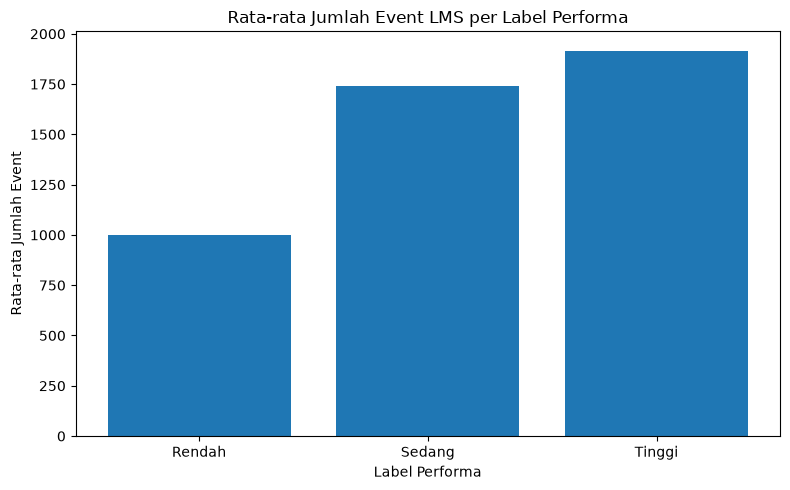

Gambar disimpan ke: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\09_avg_total_events_by_label.png


In [9]:
plot_mean_by_label(
    feature_col="total_events_full",
    title="Rata-rata Jumlah Event LMS per Label Performa",
    ylabel="Rata-rata Jumlah Event",
    output_filename="09_avg_total_events_by_label.png"
)

# Cell 10 — Grafik active days per label

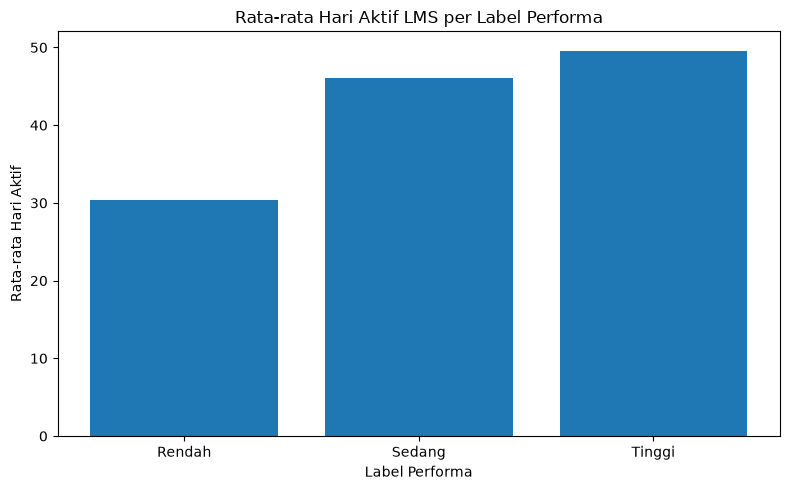

Gambar disimpan ke: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\09_avg_active_days_by_label.png


In [10]:
plot_mean_by_label(
    feature_col="active_days",
    title="Rata-rata Hari Aktif LMS per Label Performa",
    ylabel="Rata-rata Hari Aktif",
    output_filename="09_avg_active_days_by_label.png"
)

# Cell 11 — Grafik frekuensi quiz per label

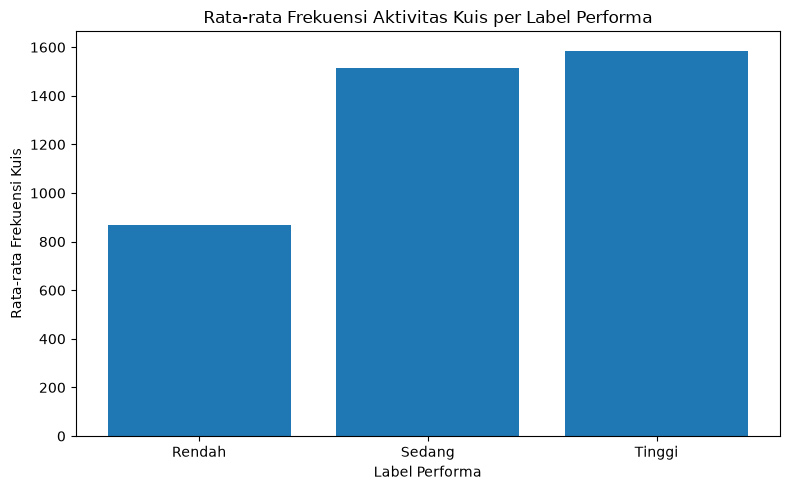

Gambar disimpan ke: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\09_avg_freq_quiz_by_label.png


In [11]:
plot_mean_by_label(
    feature_col="freq_quiz",
    title="Rata-rata Frekuensi Aktivitas Kuis per Label Performa",
    ylabel="Rata-rata Frekuensi Kuis",
    output_filename="09_avg_freq_quiz_by_label.png"
)

# Cell 12 — Grafik frekuensi material per label

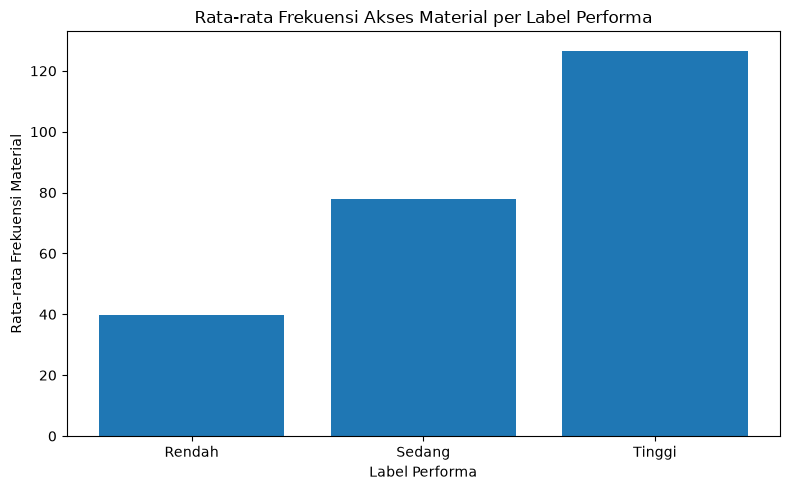

Gambar disimpan ke: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\09_avg_freq_material_by_label.png


In [12]:
plot_mean_by_label(
    feature_col="freq_material",
    title="Rata-rata Frekuensi Akses Material per Label Performa",
    ylabel="Rata-rata Frekuensi Material",
    output_filename="09_avg_freq_material_by_label.png"
)

# Cell 13 — Grafik unique transition per label

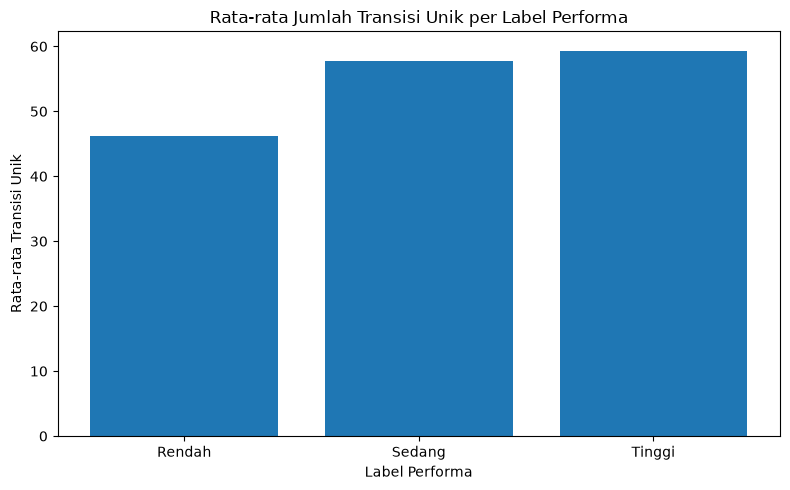

Gambar disimpan ke: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\09_avg_unique_transition_by_label.png


In [13]:
plot_mean_by_label(
    feature_col="unique_transition_count",
    title="Rata-rata Jumlah Transisi Unik per Label Performa",
    ylabel="Rata-rata Transisi Unik",
    output_filename="09_avg_unique_transition_by_label.png"
)

# Cell 14 — Boxplot total event per label

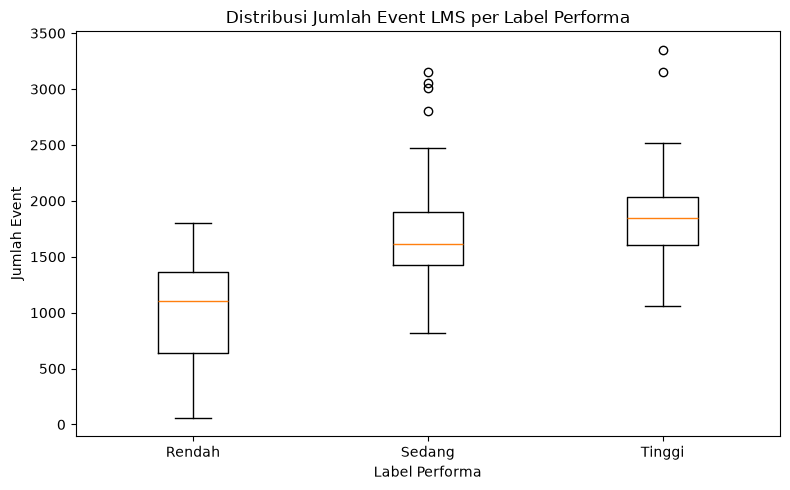

Gambar disimpan ke: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\09_boxplot_total_events_by_label.png


In [15]:
plt.figure(figsize=(8, 5))

data_to_plot = [
    feature_df[feature_df["label_performance"] == label]["total_events_full"]
    for label in label_order
]

plt.boxplot(data_to_plot, tick_labels=label_order)
plt.title("Distribusi Jumlah Event LMS per Label Performa")
plt.xlabel("Label Performa")
plt.ylabel("Jumlah Event")
plt.tight_layout()

output_path = OUTPUT_FIGURES_DIR / "09_boxplot_total_events_by_label.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke:", output_path)

# Cell 15 — Boxplot active days per label

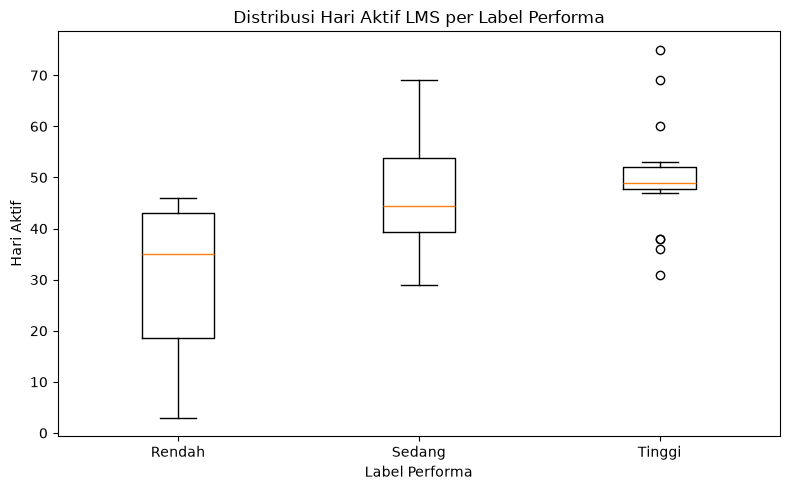

Gambar disimpan ke: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures\09_boxplot_active_days_by_label.png


In [16]:
plt.figure(figsize=(8, 5))

data_to_plot = [
    feature_df[feature_df["label_performance"] == label]["active_days"]
    for label in label_order
]

plt.boxplot(data_to_plot, tick_labels=label_order)
plt.title("Distribusi Hari Aktif LMS per Label Performa")
plt.xlabel("Label Performa")
plt.ylabel("Hari Aktif")
plt.tight_layout()

output_path = OUTPUT_FIGURES_DIR / "09_boxplot_active_days_by_label.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show()

print("Gambar disimpan ke:", output_path)

# Cell 16 — Korelasi fitur numerik dengan nilai total

In [17]:
numeric_feature_cols = feature_df.select_dtypes(include=["number"]).columns.tolist()

exclude_cols = [
    "nim",
    "nilai_total",
    "variant_id"
]

correlation_cols = [
    col for col in numeric_feature_cols
    if col not in exclude_cols
]

correlations_with_score = (
    feature_df[correlation_cols + ["nilai_total"]]
    .corr(numeric_only=True)["nilai_total"]
    .drop("nilai_total")
    .sort_values(ascending=False)
    .reset_index()
)

correlations_with_score.columns = ["feature", "correlation_with_nilai_total"]

display(correlations_with_score.head(20))
display(correlations_with_score.tail(20))

CORRELATION_PATH = OUTPUT_TABLES_DIR / "09_feature_correlation_with_nilai_total.csv"
correlations_with_score.to_csv(CORRELATION_PATH, index=False)

print("Tabel korelasi berhasil disimpan ke:")
print(CORRELATION_PATH)

,feature,correlation_with_nilai_total
0,unique_activity_full,0.698275
1,unique_activity_compact,0.698275
2,activity_span_days,0.695428
3,active_days,0.666953
4,unique_transition_count,0.651318
5,act_quiz_started,0.630954
6,act_quiz_submitted,0.616314
7,tr_submitted_to_quiz_module,0.602415
8,total_events_full,0.580659
9,act_quiz_summary_viewed,0.579562


,feature,correlation_with_nilai_total
34,freq_course,0.350826
35,act_course_viewed,0.350826
36,freq_assignment,0.339397
37,avg_events_per_active_day,0.337600
38,act_assignment_viewed,0.327623
39,act_assignment_status_viewed,0.283132
40,ratio_material,0.258699
41,act_quiz_access_prevented,0.254694
42,freq_forum,0.236004
43,act_forum_viewed,0.230399


Tabel korelasi berhasil disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\09_feature_correlation_with_nilai_total.csv


# Cell 17 — Top fitur pembeda sederhana antar label

In [18]:
label_mean_features = (
    feature_df
    .groupby("label_performance", observed=False)[available_features]
    .mean()
    .reindex(label_order)
    .T
)

label_mean_features["selisih_tinggi_rendah"] = (
    label_mean_features["Tinggi"] - label_mean_features["Rendah"]
)

label_mean_features["rasio_tinggi_rendah"] = (
    label_mean_features["Tinggi"] / label_mean_features["Rendah"].replace(0, pd.NA)
)

label_mean_features = label_mean_features.sort_values(
    "selisih_tinggi_rendah",
    ascending=False
)

display(label_mean_features.head(20))

LABEL_MEAN_FEATURES_PATH = OUTPUT_TABLES_DIR / "09_label_mean_feature_difference.csv"
label_mean_features.to_csv(LABEL_MEAN_FEATURES_PATH)

print("Tabel perbedaan rata-rata fitur berhasil disimpan ke:")
print(LABEL_MEAN_FEATURES_PATH)

label_performance,Rendah,Sedang,Tinggi,selisih_tinggi_rendah,rasio_tinggi_rendah
total_events_full,1000.866667,1739.000000,1916.500000,915.633333,1.914840
freq_quiz,866.600000,1513.129630,1586.000000,719.400000,1.830141
total_events_compact,791.400000,1382.574074,1504.050000,712.650000,1.900493
act_quiz_viewed,336.533333,612.833333,633.050000,296.516667,1.881092
act_quiz_updated,327.800000,593.888889,617.800000,290.000000,1.884686
tr_quiz_viewed_to_quiz_updated,256.000000,467.370370,481.550000,225.550000,1.881055
tr_quiz_updated_to_quiz_viewed,235.066667,430.814815,436.450000,201.383333,1.856707
freq_course,69.866667,112.296296,167.200000,97.333333,2.393130
freq_material,39.800000,78.018519,126.650000,86.850000,3.182161
active_days,30.333333,46.092593,49.600000,19.266667,1.635165


Tabel perbedaan rata-rata fitur berhasil disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\09_label_mean_feature_difference.csv


# Cell 18 — Simpan dataset analisis performa

In [19]:
ANALYSIS_OUTPUT_PATH = PROCESSED_DIR / "09_learning_pattern_by_performance.csv"

feature_df.to_csv(ANALYSIS_OUTPUT_PATH, index=False)

print("Dataset analisis pola performa disimpan ke:")
print(ANALYSIS_OUTPUT_PATH)

Dataset analisis pola performa disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\data\processed\09_learning_pattern_by_performance.csv


## Kesimpulan Analisis Pola Berdasarkan Performa

Pada tahap ini, fitur hasil process mining dianalisis berdasarkan tiga kategori performa akademik, yaitu Rendah, Sedang, dan Tinggi. Analisis dilakukan untuk melihat perbedaan karakteristik proses belajar mahasiswa berdasarkan jumlah aktivitas, hari aktif, frekuensi kategori aktivitas, variasi aktivitas, dan pola transisi.

Hasil ringkasan menunjukkan bahwa mahasiswa dengan performa Tinggi memiliki rata-rata jumlah event LMS yang lebih besar dibandingkan kelompok Sedang dan Rendah. Kelompok Tinggi memiliki rata-rata 1.916,50 event, sedangkan kelompok Sedang memiliki rata-rata 1.739,00 event dan kelompok Rendah memiliki rata-rata 1.000,87 event. Pola serupa juga terlihat pada jumlah hari aktif. Kelompok Tinggi memiliki rata-rata 49,60 hari aktif, kelompok Sedang 46,09 hari aktif, dan kelompok Rendah 30,33 hari aktif.

Dari sisi aktivitas kuis, kelompok Tinggi memiliki rata-rata frekuensi aktivitas kuis sebesar 1.586,00, lebih tinggi dibandingkan kelompok Sedang sebesar 1.513,13 dan kelompok Rendah sebesar 866,60. Selain itu, kelompok Tinggi juga menunjukkan frekuensi akses material yang lebih tinggi, yaitu 126,65, dibandingkan kelompok Sedang sebesar 78,02 dan kelompok Rendah sebesar 39,80. Hal ini menunjukkan bahwa mahasiswa dengan performa lebih tinggi tidak hanya aktif pada aktivitas kuis, tetapi juga cenderung lebih banyak mengakses material pembelajaran.

Perbedaan juga terlihat pada variasi aktivitas dan transisi. Kelompok Tinggi memiliki rata-rata jumlah aktivitas unik sebesar 17,30 dan rata-rata transisi unik sebesar 59,35. Nilai tersebut lebih tinggi dibandingkan kelompok Sedang dan Rendah. Temuan ini menunjukkan bahwa mahasiswa dengan performa lebih tinggi memiliki pola interaksi LMS yang lebih bervariasi dan tidak hanya berulang pada satu jenis aktivitas.

Hasil korelasi dengan nilai total menunjukkan bahwa fitur yang memiliki hubungan positif cukup kuat meliputi jumlah aktivitas unik, rentang aktivitas, hari aktif, jumlah transisi unik, aktivitas Quiz Started, aktivitas Quiz Submitted, total event, dan frekuensi aktivitas kuis. Fitur `unique_activity_full`, `unique_activity_compact`, `activity_span_days`, `active_days`, dan `unique_transition_count` menjadi fitur dengan korelasi positif tertinggi terhadap nilai total. Hal ini menunjukkan bahwa nilai akademik mahasiswa cenderung berkaitan dengan intensitas, konsistensi, dan variasi aktivitas belajar pada LMS.

Namun, hasil ini tetap bersifat deskriptif dan korelasional, sehingga tidak dapat langsung disimpulkan sebagai hubungan sebab-akibat. Temuan ini digunakan sebagai dasar untuk memahami pola perbedaan aktivitas belajar antar kelompok performa dan sebagai landasan untuk tahap pemodelan machine learning.
